In [11]:
import numpy
import os
import glob
import tifffile

from tiffwrapper import make_composite
from tqdm.auto import tqdm
from matplotlib import pyplot

PATH = "/home-local2/projects/FLCDataset/scraping-multichannel-sted"

In [8]:
def read_image_and_metadata(path):
    image = tifffile.imread(path)
    metadata = {
        "shape" : image.shape,
        "min" : image.min(),
        "max" : image.max(),
        "dtype" : image.dtype,
        "sum" : image.sum(),
    }
    return image, metadata

files = glob.glob(os.path.join(PATH, "*.tif"))
print(len(files), "files found")

65357 files found


In [9]:
stats = {}
for image_path in tqdm(files):
    image, metadata = read_image_and_metadata(image_path)
    stats[os.path.basename(image_path)] = metadata

  0%|          | 0/65357 [00:00<?, ?it/s]

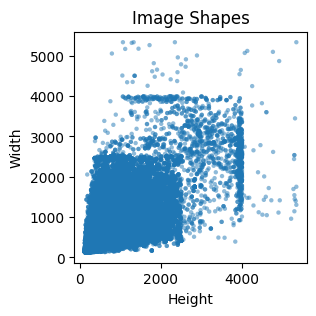

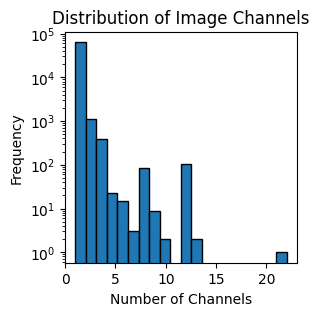

In [13]:
shapes = []
for k, v in stats.items():
    s = v["shape"]
    if len(s) == 2:
        s = (1, s[0], s[1])
    shapes.append(s)
shapes = numpy.array(shapes)

fig, ax = pyplot.subplots(figsize=(3, 3))
ax.scatter(shapes[:, 1], shapes[:, 2], alpha=0.5, s=10, edgecolor="none",)
ax.set_xlabel("Height")
ax.set_ylabel("Width")
ax.set_title("Image Shapes")
pyplot.show()

fig, ax = pyplot.subplots(figsize=(3, 3))
ax.hist(shapes[:, 0], bins=20, edgecolor="black")
ax.set_yscale("log")
ax.set_xlabel("Number of Channels")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Image Channels")
pyplot.show()

In [ ]:
# Find possible duplicates
from collections import defaultdict

duplicates = defaultdict(list)
for k, v in stats.items():
    key = (v["shape"], v["min"], v["max"], v["dtype"], v["sum"])
    duplicates[key].append(k)

print(len(duplicates), "unique images found")
for key, paths in duplicates.items():
    if len(paths) > 1:
        print(f"Possible duplicates: {paths}")


23860 unique images found
